In [1]:
import pickle


data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
with open(data_path, 'rb') as f:
    all_data = pickle.load(f)

positive_samples = all_data[:126] # number of positive samples
unlabeled_samples = all_data[126:]

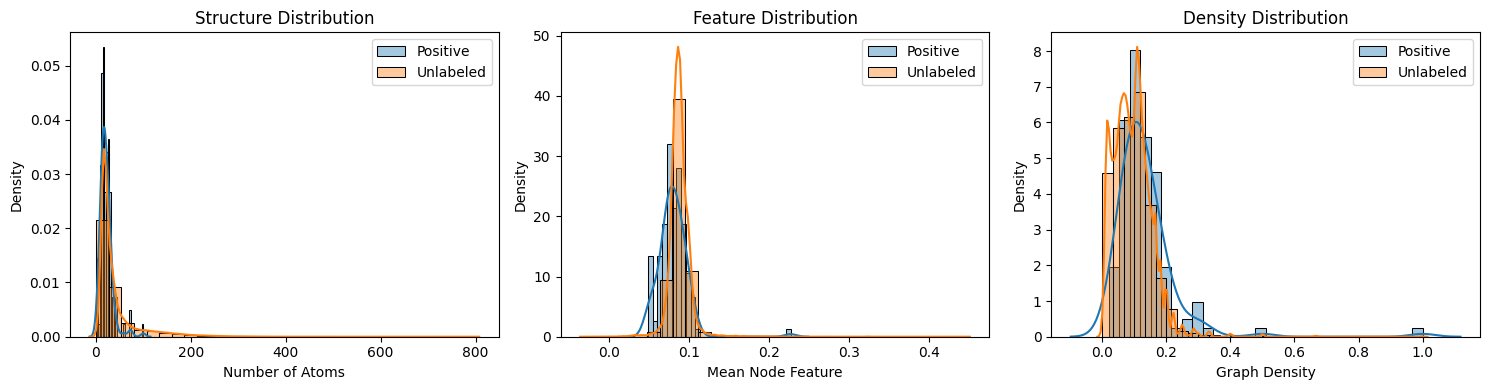

In [8]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_properties(dataset):
    n_nodes = []
    mean_feat = []
    density = []

    for data in dataset:
        # Structure
        n = data.n_nodes
        n_nodes.append(n)

        # Feature（节点特征均值）
        mean_feat.append(data.x.mean().item())

        # Density（图密度）
        e = data.n_edges
        d = e / (n * (n - 1) + 1e-6)
        density.append(d)

    return np.array(n_nodes), np.array(mean_feat), np.array(density)

# 提取两个数据集
n1, f1, d1 = get_properties(positive_samples)
n2, f2, d2 = get_properties(unlabeled_samples)

# -------------------------
# 3. 画图（3个子图）
# -------------------------
plt.figure(figsize=(15, 4))

# ---- (1) Structure ----
plt.subplot(1, 3, 1)
sns.histplot(n1, bins=30, stat='density', alpha=0.4, label='Positive')
sns.histplot(n2, bins=30, stat='density', alpha=0.4, label='Unlabeled')
sns.kdeplot(n1)
sns.kdeplot(n2)
plt.xlabel('Number of Atoms')
plt.title('Structure Distribution')
plt.legend()

# ---- (2) Feature ----
plt.subplot(1, 3, 2)
sns.histplot(f1, bins=30, stat='density', alpha=0.4, label='Positive')
sns.histplot(f2, bins=30, stat='density', alpha=0.4, label='Unlabeled')
sns.kdeplot(f1)
sns.kdeplot(f2)
plt.xlabel('Mean Node Feature')
plt.title('Feature Distribution')
plt.legend()

# ---- (3) Density ----
plt.subplot(1, 3, 3)
sns.histplot(d1, bins=30, stat='density', alpha=0.4, label='Positive')
sns.histplot(d2, bins=30, stat='density', alpha=0.4, label='Unlabeled')
sns.kdeplot(d1)
sns.kdeplot(d2)
plt.xlabel('Graph Density')
plt.title('Density Distribution')
plt.legend()

plt.tight_layout()
plt.show()